# Video 10: Working with Dates and Time Series Data

## Learning Objective
In this notebook I am learning how to work with dates in Pandas, how to set a datetime column as the
index, how to filter data using date ranges, and how to resample time series data.

## A Note on the Dataset
The survey dataset we used in the earlier videos does not have any date columns, so it is not a good
fit for this topic. Because of that, I am creating a small example weather dataset with a full year of
daily temperatures to practice working with dates.

## Step 1: Import Pandas and NumPy

In [1]:
import pandas as pd
import numpy as np

## Step 2: Create an Example Dataset with Dates
I will use date_range to create a full year of dates, and then generate a random temperature for each day.

In [2]:
dates = pd.date_range(start='2020-01-01', periods=365, freq='D')

In [3]:
np.random.seed(1)
temperatures = np.random.randint(20, 100, size=365)

In [4]:
weather = pd.DataFrame({'date': dates, 'temperature': temperatures})

In [5]:
weather.head()

,date,temperature
0,2020-01-01,57
1,2020-01-02,32
2,2020-01-03,92
3,2020-01-04,29
4,2020-01-05,95


## Step 3: Checking the Data Type of the Date Column

In [6]:
weather.dtypes

date           datetime64[us]
temperature             int64
dtype: object

The date column is already a proper datetime type since I created it with date_range. If I had loaded this from a csv file, I would need to convert it using pd.to_datetime.

In [7]:
weather['date'] = pd.to_datetime(weather['date'])

## Step 4: Setting the Date Column as the Index
This makes it much easier to filter and group the data by date.

In [8]:
weather.set_index('date', inplace=True)

In [9]:
weather.head()

,temperature
date,
2020-01-01,57
2020-01-02,32
2020-01-03,92
2020-01-04,29
2020-01-05,95


## Step 5: Using the dt Accessor
When I have a datetime column, I can use the dt accessor to pull out things like the day name.

In [10]:
weather.index.day_name()

Index(['Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday',
       'Tuesday', 'Wednesday', 'Thursday', 'Friday',
       ...
       'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
       'Sunday', 'Monday', 'Tuesday', 'Wednesday'],
      dtype='str', name='date', length=365)

In [11]:
weather['day_of_week'] = weather.index.day_name()

In [12]:
weather.head()

,temperature,day_of_week
date,,
2020-01-01,57,Wednesday
2020-01-02,32,Thursday
2020-01-03,92,Friday
2020-01-04,29,Saturday
2020-01-05,95,Sunday


## Step 6: Filtering by a Date Range
Now that date is the index, I can select all rows from a certain month using loc.

In [13]:
weather.loc['2020-01']

,temperature,day_of_week
date,,
2020-01-01,57,Wednesday
2020-01-02,32,Thursday
2020-01-03,92,Friday
2020-01-04,29,Saturday
2020-01-05,95,Sunday
2020-01-06,25,Monday
2020-01-07,99,Tuesday
2020-01-08,84,Wednesday
2020-01-09,36,Thursday


I can also select a range that spans multiple months.

In [14]:
weather.loc['2020-01':'2020-02']

,temperature,day_of_week
date,,
2020-01-01,57,Wednesday
2020-01-02,32,Thursday
2020-01-03,92,Friday
2020-01-04,29,Saturday
2020-01-05,95,Sunday
2020-01-06,25,Monday
2020-01-07,99,Tuesday
2020-01-08,84,Wednesday
2020-01-09,36,Thursday


## Step 7: Getting the Average Temperature for a Date Range

In [15]:
weather.loc['2020-01':'2020-02']['temperature'].mean()

np.float64(55.916666666666664)

## Step 8: Filtering by Day of the Week

In [16]:
filt = weather['day_of_week'] == 'Monday'
weather.loc[filt]

,temperature,day_of_week
date,,
2020-01-06,25,Monday
2020-01-13,26,Monday
2020-01-20,49,Monday
2020-01-27,83,Monday
2020-02-03,28,Monday
2020-02-10,90,Monday
2020-02-17,63,Monday
2020-02-24,88,Monday
2020-03-02,87,Monday


## Step 9: Resampling Time Series Data
Resample lets me group time series data into bigger time periods, like turning daily data into monthly data.

In [17]:
weather['temperature'].resample('ME').mean()

date
2020-01-31    54.483871
2020-02-29    57.448276
2020-03-31    58.580645
2020-04-30    57.966667
2020-05-31    57.225806
2020-06-30    68.033333
2020-07-31    56.838710
2020-08-31    67.967742
2020-09-30    58.433333
2020-10-31    63.838710
2020-11-30    55.100000
2020-12-31    56.533333
Freq: ME, Name: temperature, dtype: float64

## Step 10: Visualizing the Monthly Average Temperature

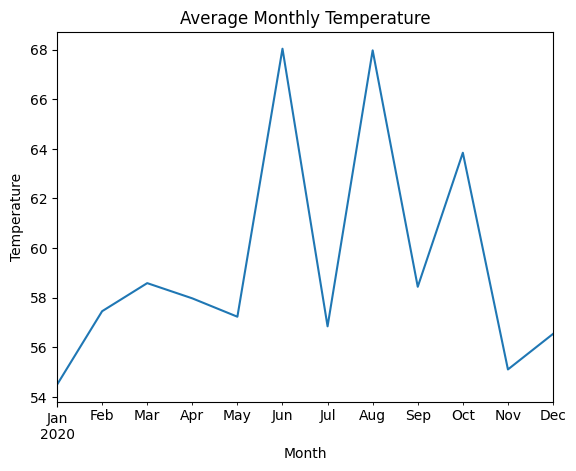

In [18]:
import matplotlib.pyplot as plt

monthly_avg = weather['temperature'].resample('ME').mean()
monthly_avg.plot()
plt.title('Average Monthly Temperature')
plt.xlabel('Month')
plt.ylabel('Temperature')
plt.show()